In [ ]:
import pandas as pd

df = pd.read_csv("udemy_courses.csv")
df.head()

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,2017-01-18T20:58:58Z,Business Finance
1,1113822,Complete GST Course & Certification - Grow You...,https://www.udemy.com/goods-and-services-tax/,True,75,2792,923,274,All Levels,39.0,2017-03-09T16:34:20Z,Business Finance
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,2016-12-19T19:26:30Z,Business Finance
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,True,95,2451,11,36,All Levels,3.0,2017-05-30T20:07:24Z,Business Finance
4,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,True,200,1276,45,26,Intermediate Level,2.0,2016-12-13T14:57:18Z,Business Finance


In [ ]:
df.columns

Index(['course_id', 'course_title', 'url', 'is_paid', 'price',
       'num_subscribers', 'num_reviews', 'num_lectures', 'level',
       'content_duration', 'published_timestamp', 'subject'],
      dtype='object')

In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df.columns = df.columns.str.strip().str.lower()

In [ ]:
import pandas as pd

df = pd.read_csv("udemy_courses.csv")
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.columns = df.columns.str.strip().str.lower()
df = df[df["level"] != "All Levels"]

df.head()

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,2016-12-19T19:26:30Z,Business Finance
4,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,True,200,1276,45,26,Intermediate Level,2.0,2016-12-13T14:57:18Z,Business Finance
6,739964,Investing And Trading For Beginners: Mastering...,https://www.udemy.com/investing-and-trading-fo...,True,65,1540,178,26,Beginner Level,1.0,2016-02-21T18:23:12Z,Business Finance
8,476268,Options Trading 3 : Advanced Stock Profit and ...,https://www.udemy.com/day-trading-stock-option...,True,195,5172,34,38,Expert Level,2.5,2015-05-28T00:14:03Z,Business Finance
15,504036,Short Selling: Learn To Sell Stocks Before The...,https://www.udemy.com/short-selling-learn-to-s...,True,75,2276,106,19,Intermediate Level,1.5,2015-06-22T21:18:35Z,Business Finance


In [ ]:
# 1) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2) Load dataset
df = pd.read_csv("udemy_courses.csv")

# 3) QUICK INSPECTION (optional but good)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3678 entries, 0 to 3677
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   course_id            3678 non-null   int64  
 1   course_title         3678 non-null   object 
 2   url                  3678 non-null   object 
 3   is_paid              3678 non-null   bool   
 4   price                3678 non-null   int64  
 5   num_subscribers      3678 non-null   int64  
 6   num_reviews          3678 non-null   int64  
 7   num_lectures         3678 non-null   int64  
 8   level                3678 non-null   object 
 9   content_duration     3678 non-null   float64
 10  published_timestamp  3678 non-null   object 
 11  subject              3678 non-null   object 
dtypes: bool(1), float64(1), int64(5), object(5)
memory usage: 319.8+ KB


In [ ]:
# Cleaning
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.columns = df.columns.str.strip().str.lower()

# Remove "All Levels"
df = df[df["level"] != "All Levels"]

In [ ]:
# Convert price column (because it has 'Free')
df["price"] = df["price"].replace("Free", 0)
df["price"] = df["price"].astype(float)

# Convert is_paid to numeric
df["is_paid"] = df["is_paid"].astype(int)

# Convert content_duration to float (if needed)
df["content_duration"] = df["content_duration"].astype(float)

df.head()

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,1,200.0,2147,23,51,All Levels,1.5,2017-01-18T20:58:58Z,Business Finance
1,1113822,Complete GST Course & Certification - Grow You...,https://www.udemy.com/goods-and-services-tax/,1,75.0,2792,923,274,All Levels,39.0,2017-03-09T16:34:20Z,Business Finance
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,1,45.0,2174,74,51,Intermediate Level,2.5,2016-12-19T19:26:30Z,Business Finance
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,1,95.0,2451,11,36,All Levels,3.0,2017-05-30T20:07:24Z,Business Finance
4,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,1,200.0,1276,45,26,Intermediate Level,2.0,2016-12-13T14:57:18Z,Business Finance


In [ ]:
df.describe()

,course_id,price,num_subscribers,num_reviews,num_lectures,content_duration
count,1.747000e+03,1747.000000,1747.000000,1747.000000,1747.000000,1747.000000
mean,7.051250e+05,58.402977,2772.778477,97.552376,33.649685,3.242101
std,3.492252e+05,56.803172,7636.561555,341.217341,37.826907,4.104829
min,1.297500e+04,0.000000,0.000000,0.000000,5.000000,0.450000
25%,4.363530e+05,20.000000,76.000000,4.000000,13.000000,1.000000
50%,7.389000e+05,40.000000,798.000000,16.000000,23.000000,2.000000
75%,9.955300e+05,75.000000,2518.000000,59.000000,39.000000,4.000000
max,1.282064e+06,200.000000,161029.000000,5924.000000,779.000000,78.500000


In [ ]:
df.groupby("level")["num_subscribers"].mean()

,num_subscribers
level,
Beginner Level,3195.459779
Expert Level,865.448276
Intermediate Level,1762.482185


In [ ]:
import numpy as np

df["log_subscribers"] = np.log1p(df["num_subscribers"])
df.head()

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject,log_subscribers
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,2016-12-19T19:26:30Z,Business Finance,7.684784
4,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,True,200,1276,45,26,Intermediate Level,2.0,2016-12-13T14:57:18Z,Business Finance,7.152269
6,739964,Investing And Trading For Beginners: Mastering...,https://www.udemy.com/investing-and-trading-fo...,True,65,1540,178,26,Beginner Level,1.0,2016-02-21T18:23:12Z,Business Finance,7.340187
8,476268,Options Trading 3 : Advanced Stock Profit and ...,https://www.udemy.com/day-trading-stock-option...,True,195,5172,34,38,Expert Level,2.5,2015-05-28T00:14:03Z,Business Finance,8.551208
15,504036,Short Selling: Learn To Sell Stocks Before The...,https://www.udemy.com/short-selling-learn-to-s...,True,75,2276,106,19,Intermediate Level,1.5,2015-06-22T21:18:35Z,Business Finance,7.730614


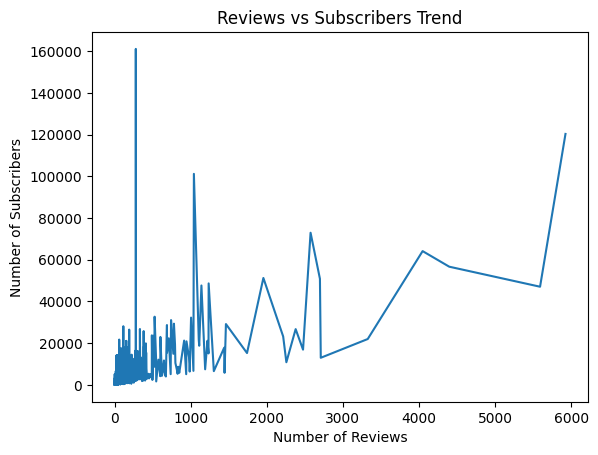

In [ ]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values(by="num_reviews")

plt.figure()
plt.plot(df_sorted["num_reviews"], df_sorted["num_subscribers"])
plt.title("Reviews vs Subscribers Trend")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Subscribers")

plt.savefig("line_plot.png")
plt.show()

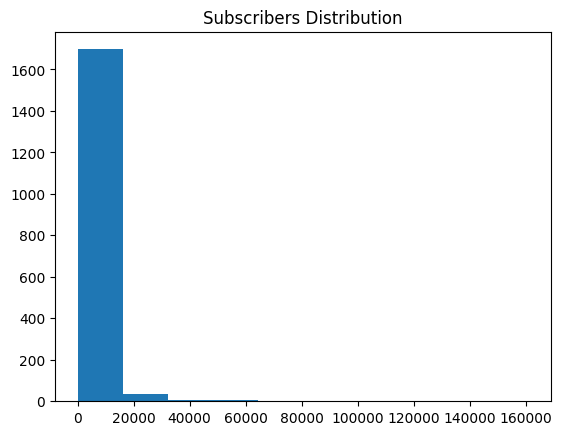

In [ ]:
plt.figure()
plt.hist(df["num_subscribers"])
plt.title("Subscribers Distribution")

plt.savefig("histogram.png")
plt.show()

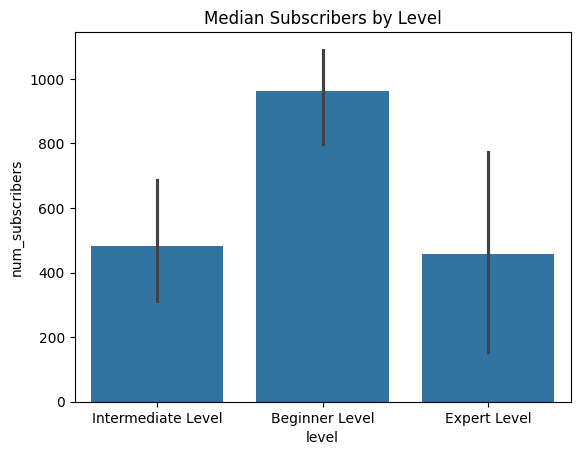

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.barplot(x="level", y="num_subscribers", data=df, estimator=np.median)
plt.title("Median Subscribers by Level")
plt.savefig("barplot_fixed.png")
plt.show()

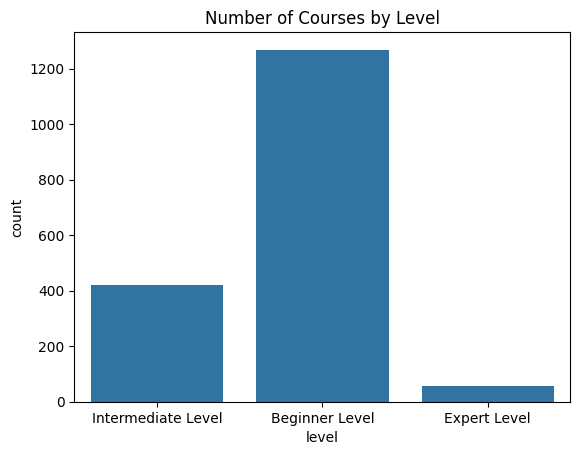

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.countplot(x="level", data=df)
plt.title("Number of Courses by Level")

plt.savefig("countplot.png")   # 👈 save BEFORE show
plt.show()

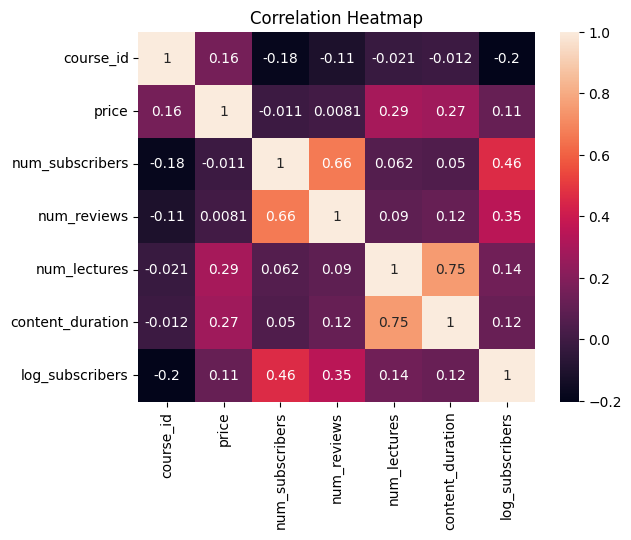

In [ ]:
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.savefig("heatmap.png")
plt.show()

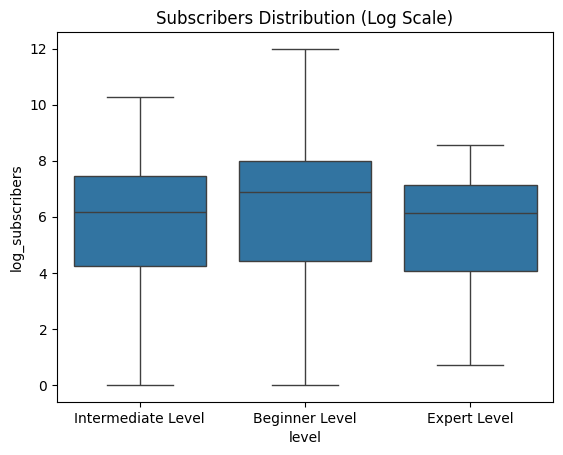

<Axes: xlabel='level', ylabel='num_subscribers'>

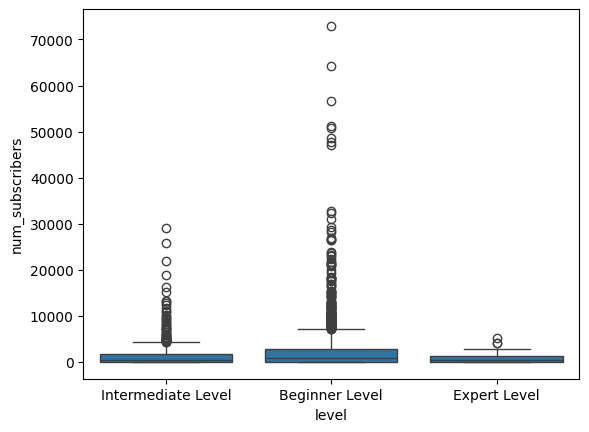

In [ ]:
df = df[df["level"] != "All Levels"]
import numpy as np

df["log_subscribers"] = np.log1p(df["num_subscribers"])

sns.boxplot(x="level", y="log_subscribers", data=df)
plt.title("Subscribers Distribution (Log Scale)")
plt.savefig("boxplot_fixed.png")
plt.show()
df_filtered = df[df["num_subscribers"] < 100000]

sns.boxplot(x="level", y="num_subscribers", data=df_filtered)

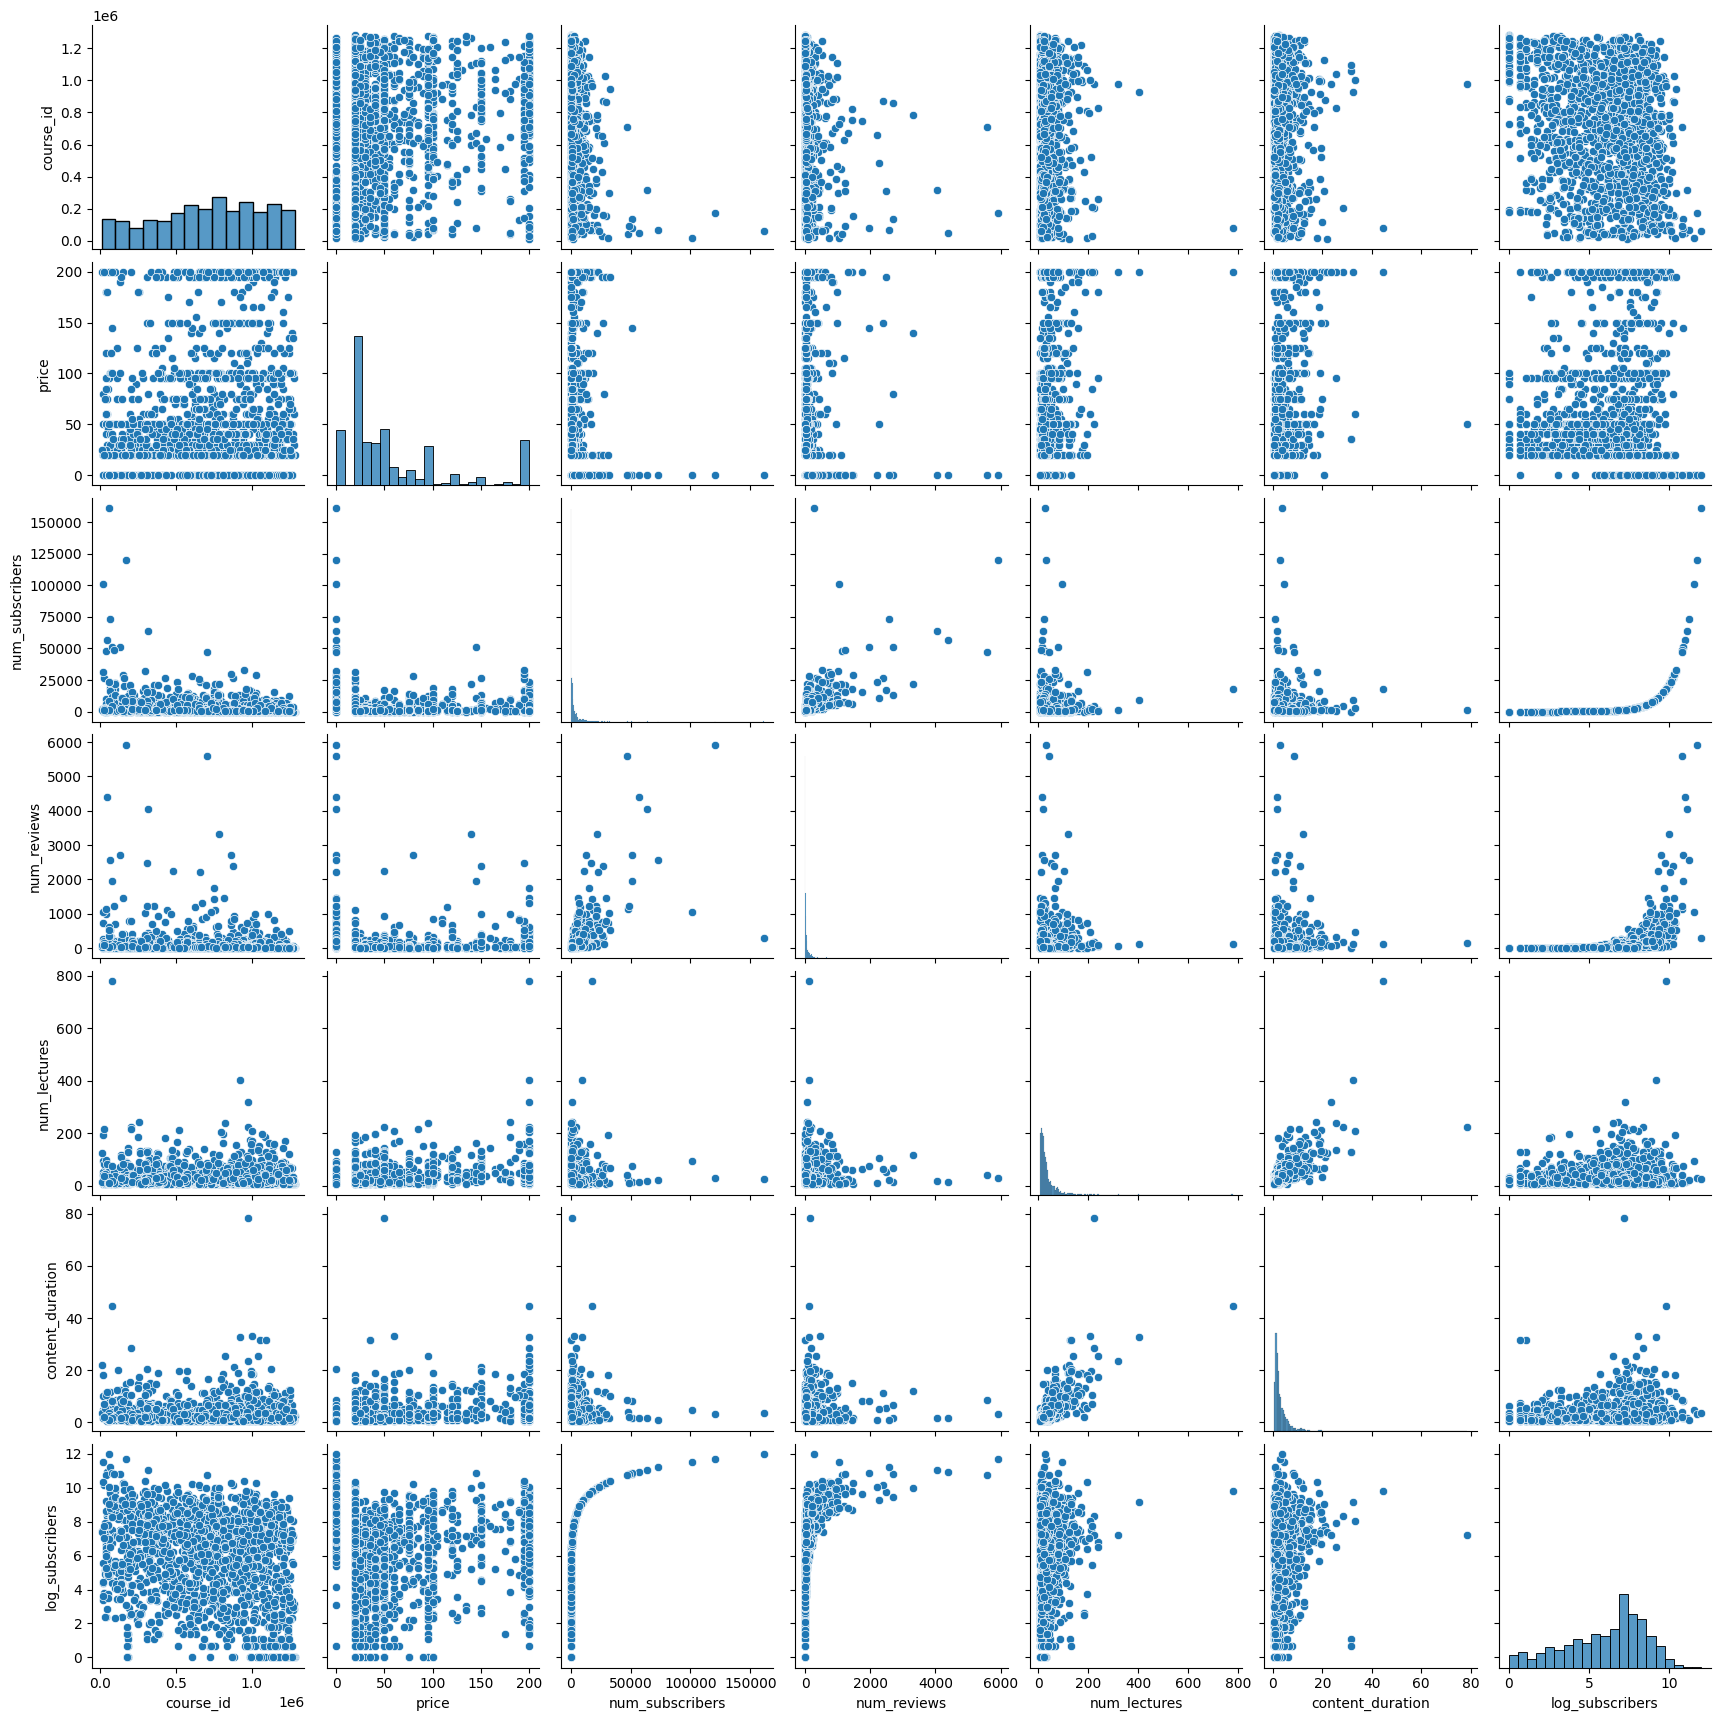

In [ ]:
g = sns.pairplot(numeric_df)
g.savefig("pairplot.png")

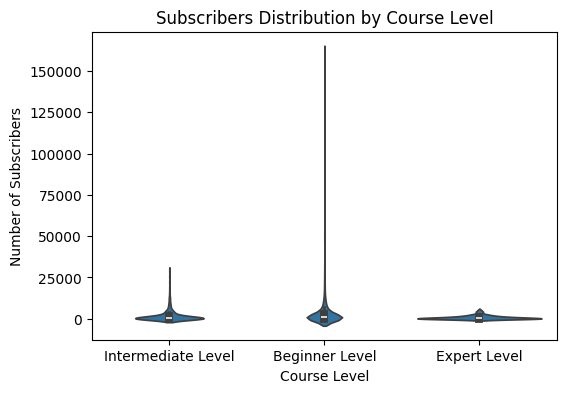

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.violinplot(x="level", y="num_subscribers", data=df)

plt.title("Subscribers Distribution by Course Level")
plt.xlabel("Course Level")
plt.ylabel("Number of Subscribers")

plt.savefig("violin_plot.png")
plt.show()

In [ ]:
# Predict Subscribers
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["num_reviews", "price"]]
y = df["num_subscribers"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.5165791593898243


In [ ]:
from google.colab import files
files.download("line_plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>